In [150]:
import time
from tqdm import tqdm

import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

In [151]:
# Fetch MNIST dataset
mnist = datasets.fetch_openml('mnist_784', version=1, as_frame=False)

# Extract data and target
x, y = mnist.data, mnist.target

In [152]:
x.shape, y.shape

((70000, 784), (70000,))

we have 70k data points 

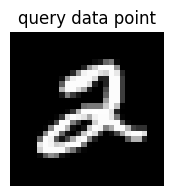

In [153]:
query_point = x[5], y[5]  # lets say this will be our query point

plt.figure(figsize=(2,2))
plt.imshow(query_point[0].reshape(28, 28), cmap = 'gray')
plt.title("query data point")
plt.axis("off")
plt.show()

given query vector, Our goal is to find most its similar vectors (based on euclidian distance)

### 1. Using full data scan - O(n)

In [154]:
# Calculate the distance of the query point from each n points
n = 60_000

start = time.time()
dist_matrix = pairwise_distances([query_point[0]], x[:n], metric='euclidean')
stop = time.time()

print(f"distance calculation time: {stop - start} seconds")

distance calculation time: 0.30697131156921387 seconds


In [155]:
s = pd.Series(dist_matrix[0])
start = time.time()
s = s.sort_values(ascending=True)  # sort ascending
stop = time.time()

print(f"sorting time: {stop - start} seconds")

sorting time: 0.007464885711669922 seconds


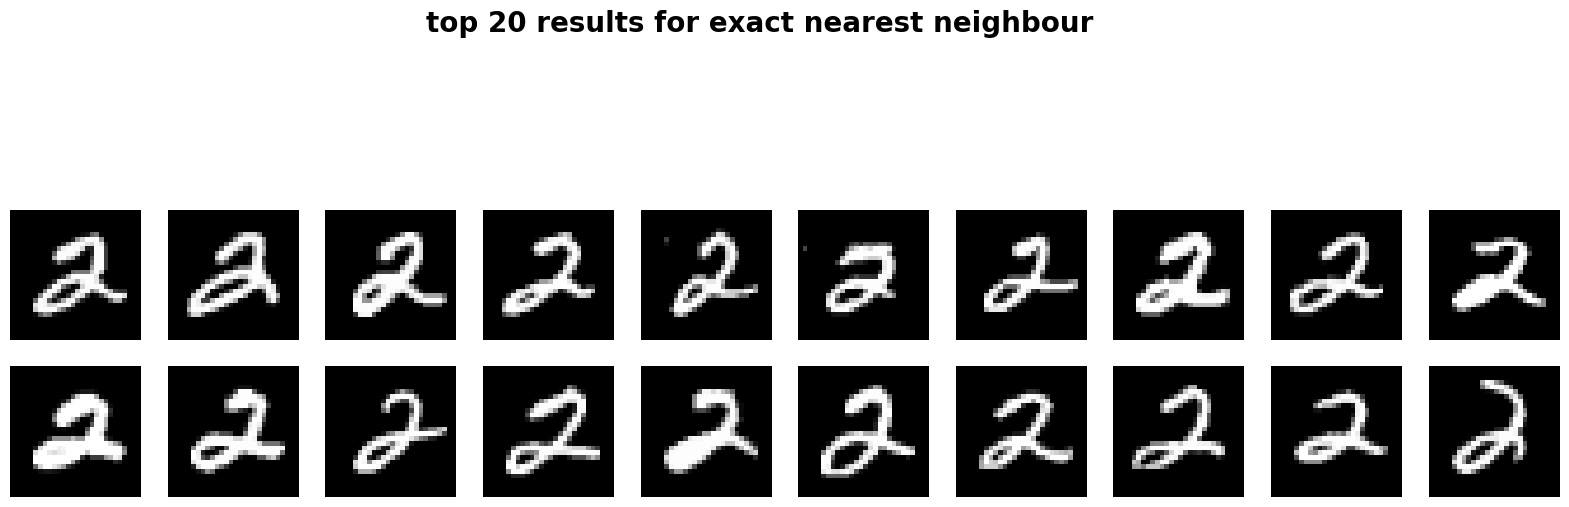

In [156]:
k = 20
top_k_points = s[:k]  # top k nearset points

fig = plt.figure(figsize=(20,20))
for i, index in enumerate(top_k_points.index):
    plt.subplot(10,10, i+1)
    plt.imshow(x[index].reshape(28, 28), cmap = 'gray')
    plt.axis("off")

fig.suptitle(f"top {k} results for exact nearest neighbour", fontsize=20, fontweight="bold")
plt.show()

### 2.Approximate Nearest Neighbor using ANNoy Algorithm

In [157]:
class Node:  # defining a node class
    def __init__(self, index):
        self.index = index
        self.p1 = None
        self.p2 = None
        self.left = None
        self.right = None
        
def split(index):  #given an index array, it will return two separate index arrays

    # randomly select two points
    random_index = np.random.choice(index, size=2, replace=False)
    p1 = x[random_index[0]]
    p2 = x[random_index[1]]

    # distance of each point from p1 and p2
    dist_matrix = pairwise_distances([p1, p2], x[index], metric='euclidean')

    #find which side each point belongs to and assign the index of that point to respective group
    groups = dist_matrix.argmin(axis=0)
    n1 = Node(index[groups == 0])  #left (close to p1)
    n2 = Node(index[groups == 1])  #right (close to p2)

    return n1, n2, p1, p2  #return the splitted indexes and both the points

def search(query_point, node):  #using query point, traverse down the tree and fetch leaf node index
    
    if node.left is None: #reached leaf node
        return node.index
    
    dist = pairwise_distances([query_point], [node.p1, node.p2], metric='euclidean')
    if dist[0, 0] < dist[0,1]:
        return search(query_point, node.left)  # search on left side
    else:
        return search(query_point, node.right)  # search on right side

def annoy(node: Node):
    global max_samples_leaf
    if node.index.size <= max_samples_leaf:  #if max samples reached, stop splitting 
        return
    
    node.left, node.right, node.p1, node.p2 = split(node.index) #split node
    
    annoy(node.left)
    annoy(node.right)


In [163]:
n = 60_000  #no of points to build your tree
max_samples_leaf = 1000 # max samples for each leaf
index = np.arange(n)  #your initial index
root = Node(index)   # root node

#measure tree building time
start = time.time()
annoy(root)
stop = time.time()
print(f"tree building time: {stop - start} seconds")

tree building time: 6.254923582077026 seconds


In [164]:
start = time.time()
top_k_index = search(query_point[0], root) #Traverse the tree to find the similar points to that query
stop = time.time()
print(f"tree traversal time: {stop - start} seconds")

tree traversal time: 0.005132436752319336 seconds


In [165]:
# Now the distance calculation narrows down to a few promising points
start = time.time()
dist_matrix = pairwise_distances([query_point[0]], x[top_k_index], metric='euclidean')
stop = time.time()

print(f"distance calculation time: {stop - start} seconds")

distance calculation time: 0.010940313339233398 seconds


- that's a massive speed gain,
- here O(n) -> log2(n / max_samples_leaf) + max_samples_leaf + max_samples_leaf.log(max_samples_leaf)
- tree traversal + distance calculation for just max_samples_leaf points + sorting 

In [168]:
s = pd.Series(dist_matrix[0])
s.index = top_k_index
start = time.time()
s = s.sort_values(ascending=True)  # sort ascending
stop = time.time()

print(f"sorting time: {stop - start} seconds")

sorting time: 0.0 seconds


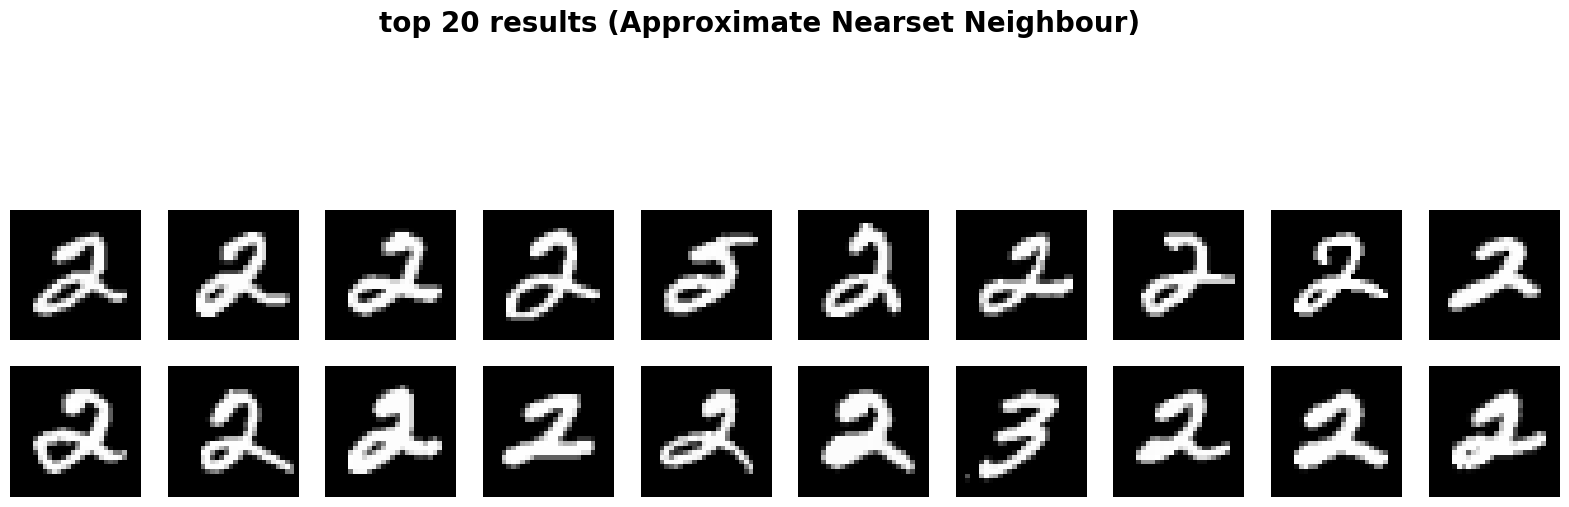

In [169]:
k = 20
top_k_points = s[:k]  # top k points

fig = plt.figure(figsize=(20,20))
for i, index in enumerate(top_k_points.index):
    plt.subplot(10,10, i+1)
    plt.imshow(x[index].reshape(28, 28), cmap = 'gray')
    plt.axis("off")

fig.suptitle(f"top {k} results (Approximate Nearset Neighbour)", fontsize=20, fontweight="bold")
plt.show()

These are the results for one single tree. 

#### lat's calculate the depth for 300 such trees and plot the histogram. 

In [ ]:
def depth(node):
    temp = node
    d = 0
    while temp is not None:
        temp = temp.left
        d+=1
    return d

In [120]:
from tqdm import tqdm
n = 60_000  #no of points to build your tree
max_samples_leaf = 1000 # max samples for each leaf
d = []

for i in tqdm(range(300)):
    index = np.arange(n)  #your initial index
    root = Node(index)   # root node
    annoy(root)
    d.append(depth(root))

100%|██████████| 300/300 [37:58<00:00,  7.59s/it]


In [140]:
theoretical_depth = np.log2(60_000/1000)
theoretical_depth

5.906890595608519

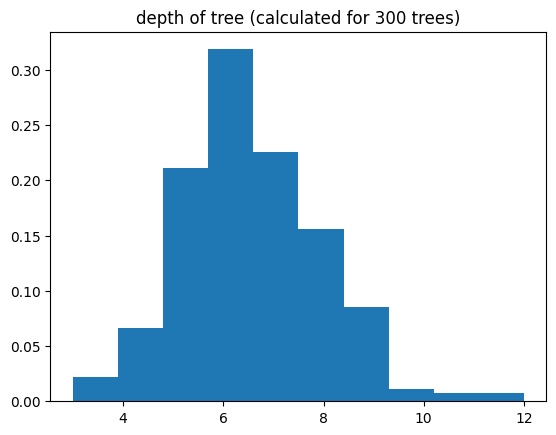

In [137]:
plt.hist(d, density=True, bins = 10)
plt.title("depth of tree (calculated for 300 trees)")
plt.show()

In [143]:
#median depth
np.median(d)

6.0

very close to our theoretical calculation of 5.9